In [61]:
!pip install -U langgraph

In [62]:
!pip install pydantic

In [63]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated
from pydantic import BaseModel,field_validator,Field
import operator

In [64]:
class EvaluationSchema(BaseModel):
  feedback:str=Field(description="Detailed feedback for the essay")
  score:float=Field(description="Score of the essay out of 10",ge=0 ,le=10)

In [65]:
from google.colab import userdata
groq_api_key=userdata.get('GROQ_API_KEY')

In [66]:
!pip install langchain_groq

In [67]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage

model = ChatGroq(model="openai/gpt-oss-120b",api_key=groq_api_key)

In [68]:
model_proper_schema=model.with_structured_output(EvaluationSchema,method="json_schema")

In [69]:
essay = """Artificial Intelligence, commonly known as AI, is one of the most important technologies of the modern world. It refers to the ability of machines and computers to perform tasks that normally require human intelligence, such as learning, problem-solving, understanding language, and recognizing images. AI is already being used in many areas of our daily lives. Virtual assistants, recommendation systems, self-driving technologies, online customer support, and medical diagnosis are some examples.

AI can improve productivity, save time, and help people make better decisions by analyzing large amounts of data quickly. It also has the potential to support education, healthcare, agriculture, and scientific research. However, AI also creates challenges such as job displacement, privacy concerns, misinformation, and the misuse of technology. Therefore, AI should be developed and used responsibly. With proper rules, human supervision, and ethical practices, Artificial Intelligence can become a powerful tool for improving society and creating new opportunities."""

In [70]:
output=model_proper_schema.invoke(essay)

In [71]:
output.score

8.0

In [72]:
class EssayState(TypedDict):
  essay:str
  language_feedback:str
  analysis_feedback:str
  clarity_feedback:str
  overall_feedback:str
  individual_scores: Annotated[list[float], operator.add]
  avg_score:float

In [73]:
def evaluate_language(state:EssayState):
  prompt=f"evaluate the language quality of the following essay and provide the feedback and assign a score out of 10 {state['essay']}"
  output=model_proper_schema.invoke(prompt)
  return {
      'language_feedback':output.feedback,
      'individual_scores':[output.score]
  }


def evaluate_analysis(state:EssayState):

  prompt=f"evaluate the depth analysis  of the following essay and provide the feedback and assign a score out of 10 {state['essay']}"
  output=model_proper_schema.invoke(prompt)
  return {
      'analysis_feedback':output.feedback,
      'individual_scores':[output.score]
  }



def evaluate_thought(state:EssayState):
  prompt=f"evaluate the clarity of the thought of the following essay and provide the feedback and assign a score out of 10 {state['essay']}"
  output=model_proper_schema.invoke(prompt)
  return {
      'clarity_feedback':output.feedback,
      'individual_scores':[output.score]
  }



def final_evaluation(state: EssayState):

    prompt = f"""
Based on all the feedback below, create a summarized feedback.

Language feedback:
{state['language_feedback']}

Analysis feedback:
{state['analysis_feedback']}

Clarity feedback:
{state['clarity_feedback']}
"""

    overall_output = model_proper_schema.invoke(prompt)

    overall_feedback = overall_output.feedback

    average_score = sum(state['individual_scores']) / len(state['individual_scores'])

    return {
        "overall_feedback": overall_feedback,
        "avg_score": average_score
    }

In [74]:
graph=StateGraph(EssayState)
graph.add_node('evaluate_analysis',evaluate_analysis)
graph.add_node('evaluate_language',evaluate_language)
graph.add_node('evaluate_thought',evaluate_thought)
graph.add_node('final_evaluation',final_evaluation)

graph.add_edge(START,'evaluate_analysis')
graph.add_edge(START,'evaluate_language')
graph.add_edge(START,'evaluate_thought')
graph.add_edge('evaluate_analysis','final_evaluation')
graph.add_edge('evaluate_language','final_evaluation')
graph.add_edge('evaluate_thought','final_evaluation')
graph.add_edge('final_evaluation',END)
workflow=graph.compile()

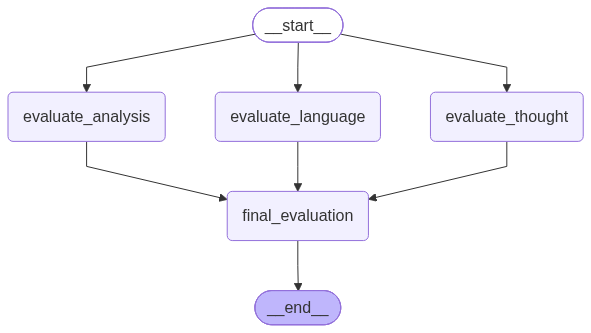

In [75]:
workflow

In [76]:
intial_state={
    'essay':"""Artificial Intelligence, commonly known as AI, is one of the most important technologies of the modern world. It refers to the ability of machines and computers to perform tasks that normally require human intelligence, such as learning, problem-solving, understanding language, and recognizing images. AI is already being used in many areas of our daily lives. Virtual assistants, recommendation systems, self-driving technologies, online customer support, and medical diagnosis are some examples.

AI can improve productivity, save time, and help people make better decisions by analyzing large amounts of data quickly. It also has the potential to support education, healthcare, agriculture, and scientific research. However, AI also creates challenges such as job displacement, privacy concerns, misinformation, and the misuse of technology. Therefore, AI should be developed and used responsibly. With proper rules, human supervision, and ethical practices, Artificial Intelligence can become a powerful tool for improving society and creating new opportunities."""
}

In [77]:
workflow.invoke(intial_state)

{'essay': 'Artificial Intelligence, commonly known as AI, is one of the most important technologies of the modern world. It refers to the ability of machines and computers to perform tasks that normally require human intelligence, such as learning, problem-solving, understanding language, and recognizing images. AI is already being used in many areas of our daily lives. Virtual assistants, recommendation systems, self-driving technologies, online customer support, and medical diagnosis are some examples.\n\nAI can improve productivity, save time, and help people make better decisions by analyzing large amounts of data quickly. It also has the potential to support education, healthcare, agriculture, and scientific research. However, AI also creates challenges such as job displacement, privacy concerns, misinformation, and the misuse of technology. Therefore, AI should be developed and used responsibly. With proper rules, human supervision, and ethical practices, Artificial Intelligence 